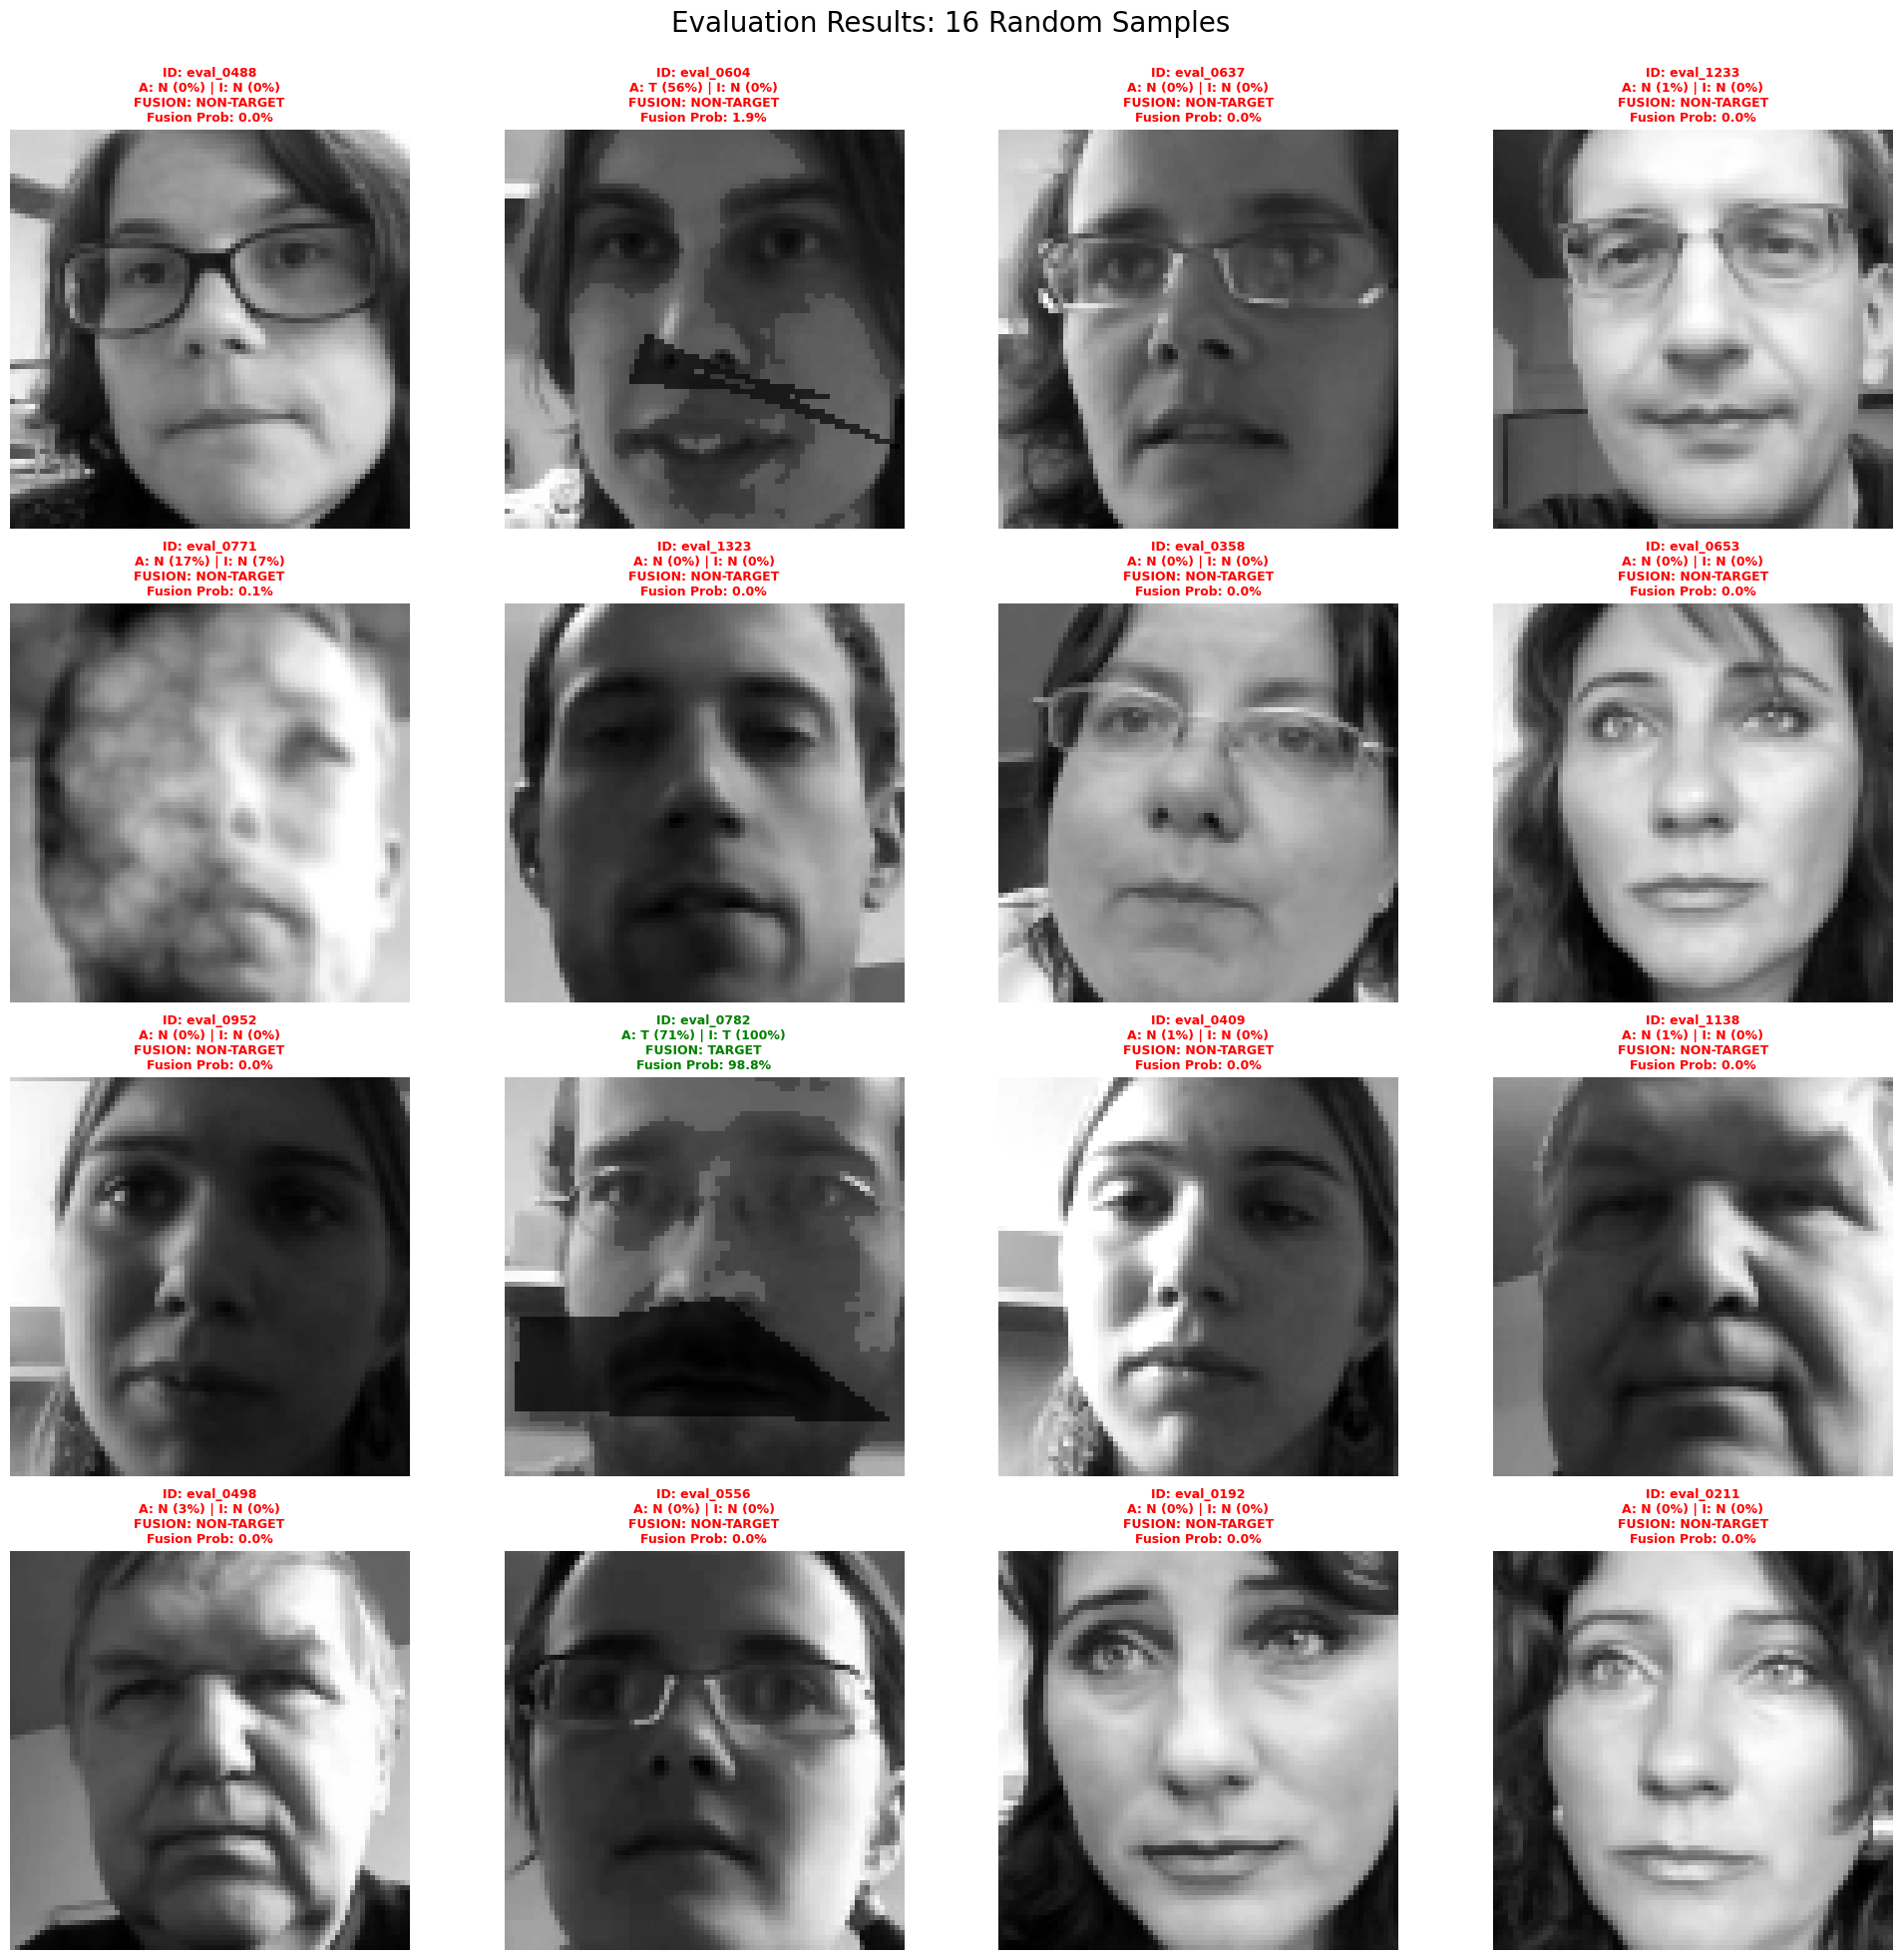

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Updated to use our new unified DataLoader
from dataset.data_loader import DataLoader
from omegaconf import OmegaConf


def load_results_map(filepath):
    """Parses submission txt files into a dictionary: {filename: (score, decision)}"""
    res_map = {}
    if os.path.exists(filepath):
        with open(filepath, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 3:
                    name, score, decision = parts
                    res_map[name] = (float(score), int(decision))
    return res_map


def visualize_random_samples(n_samples=16):
    # 1. Load configuration and paths
    cfg = OmegaConf.load("src/conf/config.yaml")
    eval_dir = cfg.paths.eval_dir

    # 2. Load Result Files
    audio_res = load_results_map("audio_SVM.txt")
    image_res = load_results_map("image_SVM.txt")
    fusion_res = load_results_map("fusion_Late_LR.txt")

    # 3. Pick random unique samples from the fusion output
    all_names = list(fusion_res.keys())
    if len(all_names) < n_samples:
        print(f"Warning: Only found {len(all_names)} samples in results.")
        n_samples = len(all_names)

    if n_samples == 0:
        print("No samples found! Make sure your text files are generated and in the correct directory.")
        return

    random_samples = random.sample(all_names, n_samples)

    # Create a 4x4 grid
    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    axes = axes.flatten()

    for i, name in enumerate(random_samples):
        # Load the image using the new unified static method
        img_path = os.path.join(eval_dir, f"{name}.png")
        try:
            img = DataLoader.load_single_image(img_path)
        except Exception:
            # Fallback if image load fails
            img = np.zeros((100, 100))

        # Retrieve scores (these are now TRUE PROBABILITIES between 0.0 and 1.0)
        s_a, d_a = audio_res.get(name, (0.0, 0))
        s_i, d_i = image_res.get(name, (0.0, 0))
        s_f, d_f = fusion_res.get(name, (0.0, 0))

        # Plotting
        axes[i].imshow(img, cmap="gray" if img.ndim == 2 else None)

        # Color coding title: Green for Target prediction, Red for Non-Target
        color = "green" if d_f == 1 else "red"

        # Formatted using percentages since they are probabilities
        title_text = (
            f"ID: {name}\n"
            f"A: {'T' if d_a else 'N'} ({s_a:.0%}) | I: {'T' if d_i else 'N'} ({s_i:.0%})\n"
            f"FUSION: {'TARGET' if d_f else 'NON-TARGET'}\n"
            f"Fusion Prob: {s_f:.1%}"
        )

        axes[i].set_title(title_text, fontsize=9, color=color, fontweight="bold")
        axes[i].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    fig.suptitle(f"Evaluation Results: {n_samples} Random Samples", fontsize=20)
    plt.show()


if __name__ == "__main__":
    visualize_random_samples(n_samples=16)